In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [19]:
# loading my dataset
df = pd.read_csv('housing_price_data.csv')
print(df.head())
print(df.shape)

        City Location_Type  Area_sqft  Bedrooms  Bathrooms  Age_years  \
0    Chennai   Near School       3674         4          1         13   
1    Kolkata  Near Highway       1360         2          2         18   
2       Pune   City Center       1794         2          2         25   
3    Kolkata  Near Highway       1630         3          1         33   
4  Hyderabad   City Center       1595         2          1         12   

   Distance_from_City_km  Garage  Price_INR  
0                     14       0   12151979  
1                      2       0    4263921  
2                     29       0    6073559  
3                      4       0    5463218  
4                     17       0    5369522  
(500, 9)


In [20]:
# checking my data before starting
print(df.info())
print("\n")
print(df.describe())
print("\nany missing values?")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   City                   500 non-null    object
 1   Location_Type          500 non-null    object
 2   Area_sqft              500 non-null    int64 
 3   Bedrooms               500 non-null    int64 
 4   Bathrooms              500 non-null    int64 
 5   Age_years              500 non-null    int64 
 6   Distance_from_City_km  500 non-null    int64 
 7   Garage                 500 non-null    int64 
 8   Price_INR              500 non-null    int64 
dtypes: int64(7), object(2)
memory usage: 35.3+ KB
None


        Area_sqft    Bedrooms   Bathrooms  Age_years  Distance_from_City_km  \
count   500.00000  500.000000  500.000000  500.00000             500.000000   
mean   2319.38400    2.398000    1.498000   20.72600              14.942000   
std    1003.67328    1.163746    0.50049

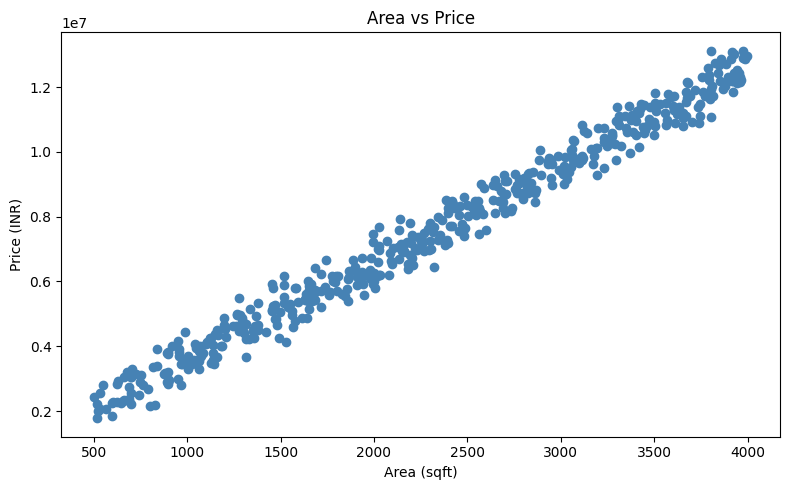

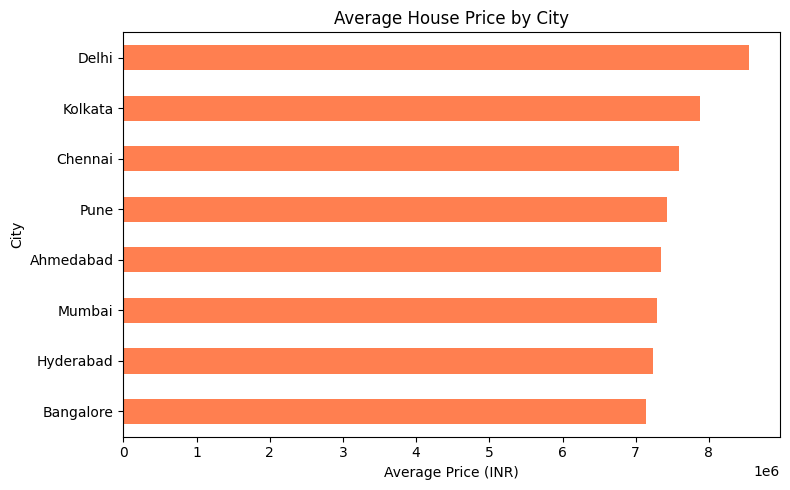

In [21]:
# wanted to see if bigger house means higher price
plt.figure(figsize=(8,5))
plt.scatter(df['Area_sqft'], df['Price_INR'], color='steelblue')
plt.title('Area vs Price')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

# checking which city has highest average price
plt.figure(figsize=(8,5))
df.groupby('City')['Price_INR'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Average House Price by City')
plt.xlabel('Average Price (INR)')
plt.tight_layout()
plt.show()

In [22]:
# these are the things i think affect house price
features = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_from_City_km', 'Garage']
X = df[features]
y = df['Price_INR']

# keeping 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# training the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Model trained successfully!
Training samples: 400
Testing samples: 100


Model Performance:
R2 Score: 0.99
RMSE: 302,177.49


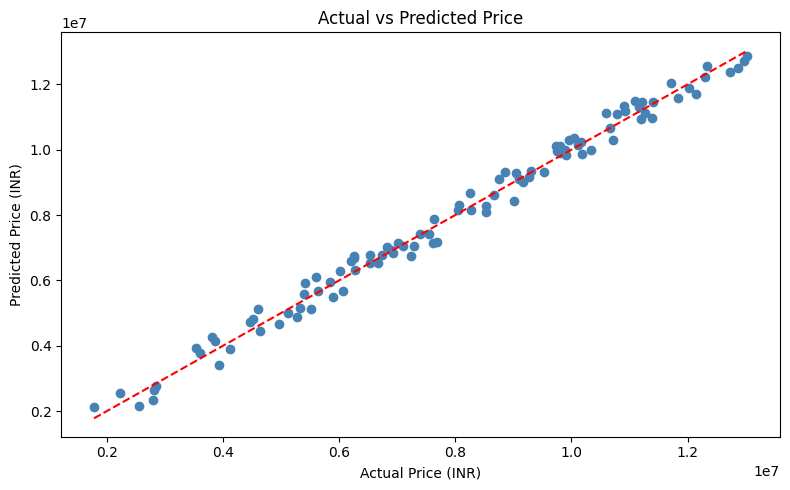

In [23]:
# let me check how well my model performed
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Performance:")
print(f"R2 Score: {r2:.2f}")
print(f"RMSE: {rmse:,.2f}")

# plotting actual vs what my model predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.tight_layout()
plt.show()

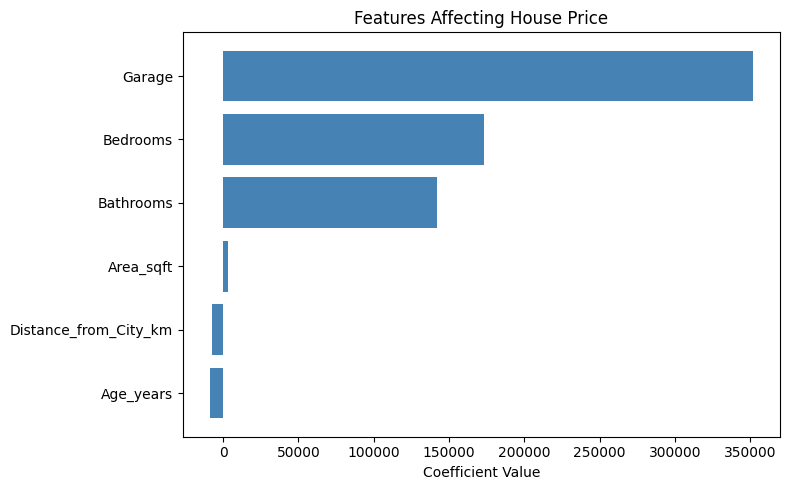

                 Feature    Coefficient
3              Age_years   -8554.171558
4  Distance_from_City_km   -7092.693531
0              Area_sqft    3003.004346
2              Bathrooms  141865.847817
1               Bedrooms  173382.866232
5                 Garage  351618.420320


In [24]:
# wanted to know which factor affects price the most
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance['Feature'], importance['Coefficient'], color='steelblue')
plt.title('Features Affecting House Price')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(importance)

In [17]:
print("="*50)
print("HOUSING PRICE PREDICTION - MY FINDINGS")
print("="*50)

print(f"""
Dataset Info:
-------------
Total Houses Analyzed: {len(df)}
Cities Covered: {df['City'].nunique()}
Features Used: {len(features)}

Model Performance:
------------------
R2 Score: {r2:.2f} ({r2*100:.1f}% accuracy)
RMSE: Rs. {rmse:,.2f}

Key Findings:
-------------
Most Expensive City: {df.groupby('City')['Price_INR'].mean().idxmax()}
Cheapest City: {df.groupby('City')['Price_INR'].mean().idxmin()}
Avg House Price: Rs. {df['Price_INR'].mean():,.2f}
Largest House: {df['Area_sqft'].max()} sqft
""")

print("="*50)
print("Analysis Complete!")
print("="*50)

HOUSING PRICE PREDICTION - MY FINDINGS

Dataset Info:
-------------
Total Houses Analyzed: 500
Cities Covered: 8
Features Used: 6

Model Performance:
------------------
R2 Score: 0.99 (98.9% accuracy)
RMSE: Rs. 302,177.49

Key Findings:
-------------
Most Expensive City: Delhi
Cheapest City: Bangalore
Avg House Price: Rs. 7,553,430.95
Largest House: 3999 sqft

Analysis Complete!
